# So sánh phân cụm RFM: k = 2, 3, 4

Đọc assignment K-Means đã lưu, không huấn luyện lại và không sửa Parquet.

**A: cấu hình/nguồn → B: cùng cohort/RFM → C: profile/nhãn → D: transition → E: Intermediate → F: tiêu chí chọn k → G: kết luận/kiểm chứng.**

Chạy **Restart Kernel → Run All**. Hướng dẫn: [EDA_RFM_Guide_VI.md](EDA_RFM_Guide_VI.md). EDA snapshot: [EDA_RFM_Parquet.ipynb](EDA_RFM_Parquet.ipynb).

## A. Cấu hình và đọc các phương án

Dùng cùng ngày chốt và đường dẫn legacy/local. Thay đường dẫn rõ ràng nếu đọc dữ liệu versioned của DAG; không trộn phiên bản nguồn. Kernel cần pandas, pyarrow, numpy, matplotlib, seaborn.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None
RUN_DATE = "2011-12-10"
RANDOM_STATE = 42
cwd = Path.cwd().resolve()
PROJECT_ROOT = (Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
                if PROJECT_ROOT_OVERRIDE else next(
                    (p for p in (cwd, *cwd.parents)
                     if (p / "scripts" / "pyspark_clean.py").is_file()), None))
if PROJECT_ROOT is None:
    raise FileNotFoundError("Check the configured repository/data path.")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
metrics = ["Recency", "Frequency", "Monetary"]

K_VALUES = (2, 3, 4)
comparison_path = PROJECT_ROOT / "data/analytics/rfm_comparison"
SCORES_PATH = PROJECT_ROOT / "data/analytics/k_selection" / RUN_DATE / "k_scores.csv"
MIN_DETAIL_PCT = 1.0
rfm_by_k = {}
for k in K_VALUES:
    path = comparison_path / f"k={k}" / f"run_date={RUN_DATE}"
    if not path.exists():
        raise FileNotFoundError("Check the configured repository/data path.")
    data = pd.read_parquet(path, engine="pyarrow").copy()
    required = {"CustomerID", "Cluster", *metrics}
    assert required.issubset(data.columns), "Missing required columns"
    for metric in metrics:
        data[metric] = pd.to_numeric(data[metric], errors="raise")
    rfm_by_k[k] = data
    print(f"k={k}: {len(data):,} customers | {path}")

k=2: 4,334 customers | C:\Users\Lenovo\Documents\Big Data\Airflow-Apache-Retail-E-Commerce-Dataset\data\analytics\rfm_comparison\k=2\run_date=2011-12-10
k=3: 4,334 customers | C:\Users\Lenovo\Documents\Big Data\Airflow-Apache-Retail-E-Commerce-Dataset\data\analytics\rfm_comparison\k=3\run_date=2011-12-10
k=4: 4,334 customers | C:\Users\Lenovo\Documents\Big Data\Airflow-Apache-Retail-E-Commerce-Dataset\data\analytics\rfm_comparison\k=4\run_date=2011-12-10


## B. Xác nhận cùng khách hàng, RFM và ngày chốt

Phải khớp CustomerID và từng giá trị R/F/M trước khi đối chiếu membership. Cùng số dòng chưa đủ chứng minh cùng cohort.

In [2]:
import numpy as np
from IPython.display import display

for k, data in rfm_by_k.items():
    assert data['CustomerID'].notna().all() and data['CustomerID'].is_unique
    assert data['Cluster'].notna().all() and data['Cluster'].nunique() == k
    values = data[['Recency', 'Frequency', 'Monetary']].to_numpy(dtype=float)
    assert np.isfinite(values).all(), 'RFM phải hữu hạn và không thiếu.'
    assert (values >= 0).all(), 'Kiểm tra dữ liệu RFM âm trước khi diễn giải/log1p.'
metrics = ["Recency", "Frequency", "Monetary"]

baseline = (
    rfm_by_k[2]
    .set_index("CustomerID")[metrics]
    .sort_index()
)

for k in [3, 4]:
    candidate = (
        rfm_by_k[k]
        .set_index("CustomerID")[metrics]
        .sort_index()
    )
    pd.testing.assert_frame_equal(baseline, candidate)

print("Đã xác nhận: cả ba phương án dùng cùng khách hàng và RFM.")

Đã xác nhận: cả ba phương án dùng cùng khách hàng và RFM.


## C. Profile và quy tắc đặt nhãn

Raw ID chỉ dùng truy vết. Xếp Monetary median tăng dần, phá hòa bằng Frequency median tăng dần rồi Recency median giảm dần. Hai đầu là Lower-value/Higher-value; k=3 có Intermediate. k=4 xếp hai cụm giữa theo Recency median để đặt Recent Moderate/Less-recent Moderate.

Profile hòa hoàn toàn hoặc hai nhóm moderate có cùng Recency median thì dừng. Nhãn tương đối trong phương án, không phải định nghĩa VIP/churn. Đổi seed có thể đổi membership; nhãn không bảo đảm ổn định.

In [3]:
profiles = []

for k, data in rfm_by_k.items():
    profile = data.groupby("Cluster").agg(
        n_customers=("CustomerID", "size"),
        recency_mean=("Recency", "mean"),
        recency_median=("Recency", "median"),
        frequency_mean=("Frequency", "mean"),
        frequency_median=("Frequency", "median"),
        monetary_mean=("Monetary", "mean"),
        monetary_median=("Monetary", "median"),
        monetary_total=("Monetary", "sum"),
        one_purchase_pct=("Frequency", lambda s: s.eq(1).mean() * 100),
    )

    for metric in metrics:
        profile[f"{metric}_q1"] = data.groupby("Cluster")[metric].quantile(0.25)
        profile[f"{metric}_q3"] = data.groupby("Cluster")[metric].quantile(0.75)

    profile["customer_pct"] = profile["n_customers"] / len(data) * 100
    profile["monetary_pct"] = (
        profile["monetary_total"] / data["Monetary"].sum() * 100
    )
    profile["k"] = k
    profiles.append(profile.reset_index())

comparison_profile = (
    pd.concat(profiles, ignore_index=True)
    .set_index(["k", "Cluster"])
    .sort_index()
)


def semantic_mapping(profile, k):
    keys = ['monetary_median', 'frequency_median', 'recency_median']
    if profile.duplicated(keys).any():
        raise ValueError('Profile hòa: cần xem lại quy tắc đặt nhãn.')
    ranked = profile.sort_values(keys, ascending=[True, True, False])
    mapping = {ranked.index[0]: 'Lower-value', ranked.index[-1]: 'Higher-value'}
    if k == 3:
        mapping[ranked.index[1]] = 'Intermediate'
    elif k == 4:
        moderate = ranked.iloc[1:-1].sort_values('recency_median')
        if moderate['recency_median'].nunique() != 2:
            raise ValueError('Recency median hòa: không thể đặt nhãn recent/less-recent.')
        mapping.update(dict(zip(moderate.index, ['Recent Moderate', 'Less-recent Moderate'])))
    return mapping

segment_orders = {
    2: ['Lower-value', 'Higher-value'],
    3: ['Lower-value', 'Intermediate', 'Higher-value'],
    4: ['Lower-value', 'Less-recent Moderate', 'Recent Moderate', 'Higher-value'],
}
semantic_maps = {}
for k, data in rfm_by_k.items():
    semantic_maps[k] = semantic_mapping(comparison_profile.loc[k], k)
    data['EDA_Segment'] = pd.Categorical(data['Cluster'].map(semantic_maps[k]),
                                     categories=segment_orders[k], ordered=True)
    assert data['EDA_Segment'].notna().all()

profile_display = comparison_profile.reset_index()
profile_display['Segment'] = [semantic_maps[k][cluster]
    for k, cluster in zip(profile_display['k'], profile_display['Cluster'])]
display(profile_display.set_index(['k', 'Segment', 'Cluster']).round(2))

n_customers  recency_mean  recency_median  \
k Segment              Cluster                                              
2 Lower-value          0               2671        134.86            97.0   
  Higher-value         1               1663         26.36            17.0   
3 Lower-value          0               1872        168.53           160.0   
  Higher-value         1                753         17.60            10.0   
  Intermediate         2               1709         44.06            30.0   
4 Less-recent Moderate 0               1050        111.16            82.5   
  Higher-value         1                691         16.54            10.0   
  Lower-value          2               1528        168.56           159.5   
  Recent Moderate      3               1065         17.22            17.0   

                                frequency_mean  frequency_median  \
k Segment              Cluster                                     
2 Lower-value          0                  1.66               1.0   
  Higher-value         1                  8.40               6.0   
3 Lower-value          0                  1.35               1.0   
  Higher-value         1                 13.43              10.0   
  Intermediate         2                  3.37               3.0   
4 Less-recent Moderate 0                  3.18               3.0   
  Higher-value         1                 14.13              10.0   
  Lower-value          2                  1.19               1.0   
  Recent Moderate      3                  3.27               3.0   

                                monetary_mean  monetary_median  \
k Segment              Cluster                                   
2 Lower-value          0               492.39           356.85   
  Higher-value         1              4462.26          2035.08   
3 Lower-value          0               358.78           292.74   
  Higher-value         1              7896.12          3640.67   
  Intermediate         2              1239.62           958.71   
4 Less-recent Moderate 0              1493.63          1018.60   
  Higher-value         1              8284.24          3901.81   
  Lower-value          2               262.89           236.03   
  Recent Moderate      3               977.95           812.68   

                                monetary_total  one_purchase_pct  Recency_q1  \
k Segment              Cluster                                                 
2 Lower-value          0            1315184.85             56.20        46.0   
  Higher-value         1            7420737.79              0.24         6.0   
3 Lower-value          0             671630.31             72.65        71.0   
  Higher-value         1            5945776.21              0.00         4.0   
  Intermediate         2            2118516.12              8.48        16.0   
4 Less-recent Moderate 0            1568308.47             10.57        59.0   
  Higher-value         1            5724410.56              0.00         4.0   
  Lower-value          2             401688.35             83.51        64.0   
  Recent Moderate      3            1041515.26             11.08         9.0   

                                Recency_q3  Frequency_q1  Frequency_q3  \
k Segment              Cluster                                           
2 Lower-value          0            215.00           1.0           2.0   
  Higher-value         1             33.00           4.0           9.0   
3 Lower-value          0            255.25           1.0           2.0   
  Higher-value         1             20.00           7.0          14.0   
  Intermediate         2             60.00           2.0           4.0   
4 Less-recent Moderate 0            144.00           2.0           4.0   
  Higher-value         1             23.00           8.0          15.0   
  Lower-value          2            262.25           1.0           1.0   
  Recent Moderate      3             25.00           2.0           4.0   

            

## D. Transition: cụm cũ đi đâu và cụm mới đến từ đâu?

Số lượng đếm khách. Phần trăm theo hàng có mỗi hàng cộng 100%; phần trăm theo cột có mỗi cột cộng 100%. Các mô hình fit riêng nên đây là đối chiếu membership, không phải cây phân chia lồng nhau.

In [4]:
labels = pd.concat(
    [
        data.set_index("CustomerID")["EDA_Segment"].rename(f"cluster_k{k}")
        for k, data in rfm_by_k.items()
    ],
    axis=1,
)

for previous_k, next_k in [(2, 3), (3, 4)]:
    print(f"\nk={previous_k} → k={next_k}: số khách hàng")
    display(pd.crosstab(
        labels[f"cluster_k{previous_k}"],
        labels[f"cluster_k{next_k}"],
    ))

    print("Tỷ lệ % theo từng hàng:")
    display(pd.crosstab(
        labels[f"cluster_k{previous_k}"],
        labels[f"cluster_k{next_k}"],
        normalize="index",
    ).mul(100).round(2))
    print('Tỷ lệ % theo từng cột (nguồn gốc của cụm mới):')
    display(pd.crosstab(
        labels[f'cluster_k{previous_k}'], labels[f'cluster_k{next_k}'],
        normalize='columns',
    ).mul(100).round(2))


k=2 → k=3: số khách hàng


cluster_k3,Lower-value,Intermediate,Higher-value
cluster_k2,,,
Lower-value,1872,799,0
Higher-value,0,910,753


Tỷ lệ % theo từng hàng:


cluster_k3,Lower-value,Intermediate,Higher-value
cluster_k2,,,
Lower-value,70.09,29.91,0.00
Higher-value,0.00,54.72,45.28


Tỷ lệ % theo từng cột (nguồn gốc của cụm mới):


...

cluster_k4,Lower-value,Less-recent Moderate,Recent Moderate,Higher-value
cluster_k3,,,,
Lower-value,1523,334,15,0
Intermediate,5,701,991,12
Higher-value,0,15,59,679


Tỷ lệ % theo từng hàng:


cluster_k4,Lower-value,Less-recent Moderate,Recent Moderate,Higher-value
cluster_k3,,,,
Lower-value,81.36,17.84,0.80,0.00
Intermediate,0.29,41.02,57.99,0.70
Higher-value,0.00,1.99,7.84,90.17


Tỷ lệ % theo từng cột (nguồn gốc của cụm mới):


cluster_k4,Lower-value,Less-recent Moderate,Recent Moderate,Higher-value
cluster_k3,,,,
Lower-value,99.67,31.81,1.41,0.00
Intermediate,0.33,66.76,93.05,1.74
Higher-value,0.00,1.43,5.54,98.26


## E. Phân tích nhóm Intermediate của k=3

Giữ tất cả transition trong bảng. Chỉ nhóm có tỷ trọng ít nhất MIN_DETAIL_PCT (mặc định 1%) số khách Intermediate được đưa vào boxplot chi tiết. Ngưỡng chỉ kiểm soát biểu đồ; mọi khách vẫn có trong bảng và tổng. Chuyển nhóm không tự chứng minh khách nằm sát biên centroid.

In [5]:
# Chọn bằng semantic label được tính từ profile.
middle_ids = rfm_by_k[3].loc[
    rfm_by_k[3]["EDA_Segment"].eq("Intermediate"), "CustomerID"
]

middle_k4 = rfm_by_k[4].loc[
    rfm_by_k[4]["CustomerID"].isin(middle_ids)
].copy()

assert len(middle_k4) == len(middle_ids)
assert middle_k4["CustomerID"].is_unique

middle_profile = middle_k4.groupby("EDA_Segment", observed=True).agg(
    n_customers=("CustomerID", "size"),
    recency_median=("Recency", "median"),
    frequency_median=("Frequency", "median"),
    monetary_median=("Monetary", "median"),
    one_purchase_pct=("Frequency", lambda s: s.eq(1).mean() * 100),
)

for metric in ["Recency", "Frequency", "Monetary"]:
    grouped = middle_k4.groupby("EDA_Segment", observed=True)[metric]
    middle_profile[f"{metric}_q1"] = grouped.quantile(0.25)
    middle_profile[f"{metric}_q3"] = grouped.quantile(0.75)

middle_profile["customer_pct"] = (
    middle_profile["n_customers"] / len(middle_k4) * 100
)

print(f"Số khách thuộc cụm trung gian k=3: {len(middle_k4):,}")
middle_profile['detailed_plot'] = middle_profile['customer_pct'].ge(MIN_DETAIL_PCT)
display(middle_profile.round(2))
assert middle_profile['n_customers'].sum() == len(middle_ids)
assert np.isclose(middle_profile['customer_pct'].sum(), 100)
main_labels = middle_profile.index[middle_profile['detailed_plot']].tolist()
excluded = middle_profile.loc[~middle_profile['detailed_plot'], ['n_customers', 'customer_pct']]
print("Input/output validation; see the displayed tables and configured paths.")
display(excluded.round(2))

Số khách thuộc cụm trung gian k=3: 1,709


,n_customers,recency_median,frequency_median,monetary_median,one_purchase_pct,Recency_q1,Recency_q3,Frequency_q1,Frequency_q3,Monetary_q1,Monetary_q3,customer_pct,detailed_plot
EDA_Segment,,,,,,,,,,,,,
Lower-value,5,38.0,1.0,527.05,60.00,36.00,38.0,1.0,2.00,372.80,612.72,0.29,False
Less-recent Moderate,701,68.0,3.0,1240.20,5.14,52.00,95.0,2.0,4.00,806.14,1905.45,41.02,True
Recent Moderate,991,18.0,3.0,778.94,10.70,10.00,25.0,2.0,4.00,472.49,1238.62,57.99,True
Higher-value,12,33.0,6.5,2302.34,0.00,31.25,41.0,6.0,8.25,1686.61,2482.99,0.70,False


Input/output validation; see the displayed tables and configured paths.


,n_customers,customer_pct
EDA_Segment,,
Lower-value,5,0.29
Higher-value,12,0.70


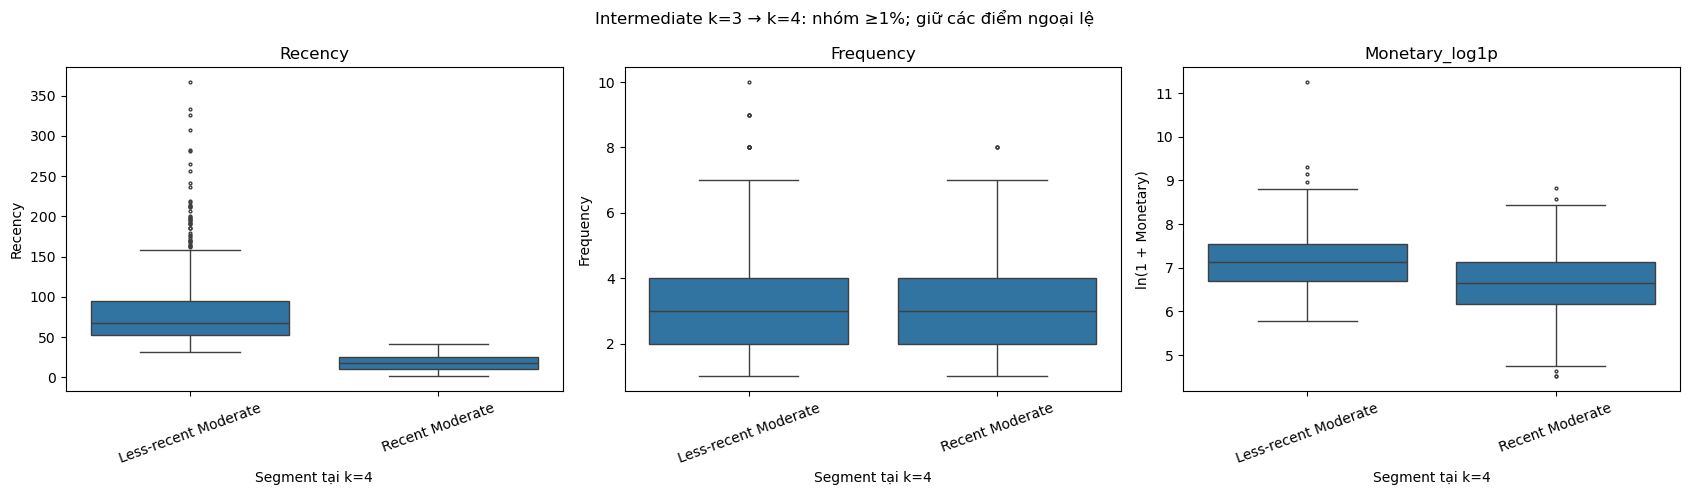

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

main_groups = middle_k4.loc[middle_k4['EDA_Segment'].isin(main_labels)].copy()
main_groups['Monetary_log1p'] = np.log1p(main_groups['Monetary'])
order = [label for label in segment_orders[4] if label in main_labels]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric in zip(axes, ['Recency', 'Frequency', 'Monetary_log1p']):
    sns.boxplot(data=main_groups, x='EDA_Segment', y=metric, order=order,
                showfliers=True, fliersize=2, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('Segment tại k=4')
    ax.tick_params(axis='x', rotation=20)
axes[2].set_ylabel('ln(1 + Monetary)')
fig.suptitle('Intermediate k=3 → k=4: nhóm ≥1%; giữ các điểm ngoại lệ')
plt.tight_layout()
plt.show()

### E1. Recency của toàn bộ Intermediate

Histogram/KDE giữ mọi khách, gồm transition nhỏ. KDE nhạy bandwidth; histogram nhạy bins. Không dùng ANOVA/Kruskal–Wallis trên chính R/F/M để chứng minh cụm khác nhau.

Một hay hai đỉnh trên Recency không đủ quyết định k=4 vì K-Means dùng không gian RFM ba chiều đã log1p và scale.

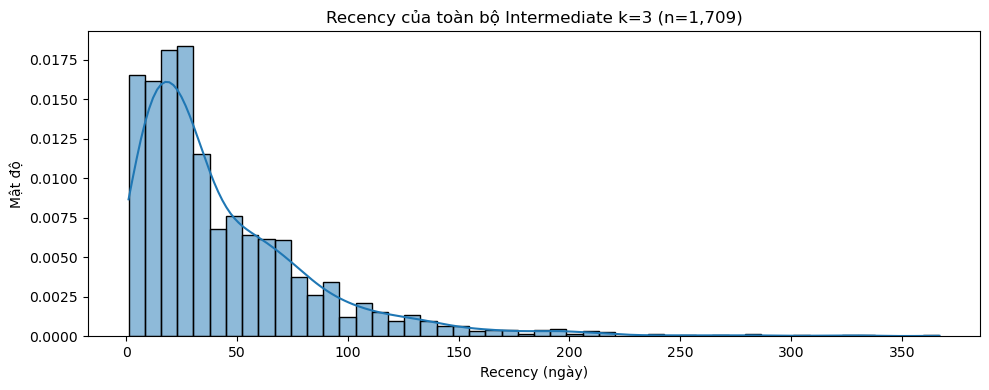

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
recency = middle_k4['Recency']
sns.histplot(recency, bins='fd', stat='density',
             kde=recency.nunique() > 1,
             kde_kws={'cut': 0, 'clip': (0, None)}, ax=ax)
ax.set(title=f'Recency của toàn bộ Intermediate k=3 (n={len(recency):,})',
       xlabel='Recency (ngày)', ylabel='Mật độ')
plt.tight_layout()
plt.show()

## F. Đọc WSSSE và silhouette khi cân nhắc k

CSV do job k-selection tạo riêng, chỉ là bằng chứng cho lần chạy đó. Notebook chưa xác nhận cùng fingerprint/seed với assignment; đối chiếu cấu hình/nguồn trước khi kết hợp. Thiếu CSV vẫn đọc được profile/transition.

WSSSE thường giảm khi tăng k; không chọn bằng giá trị nhỏ nhất. Silhouette cao hơn là tốt hơn theo khoảng cách đang dùng nhưng chưa quyết định tính hữu ích nghiệp vụ.

,k,wssse,silhouette
0,2,6469.301221,0.623811
1,3,4850.529374,0.500450
2,4,3924.874617,0.491780
3,5,3265.018788,0.480526
4,6,2836.575165,0.467632
5,7,2527.779469,0.457157
6,8,2337.333516,0.415102
7,9,2172.425685,0.406571
8,10,2006.731588,0.414667


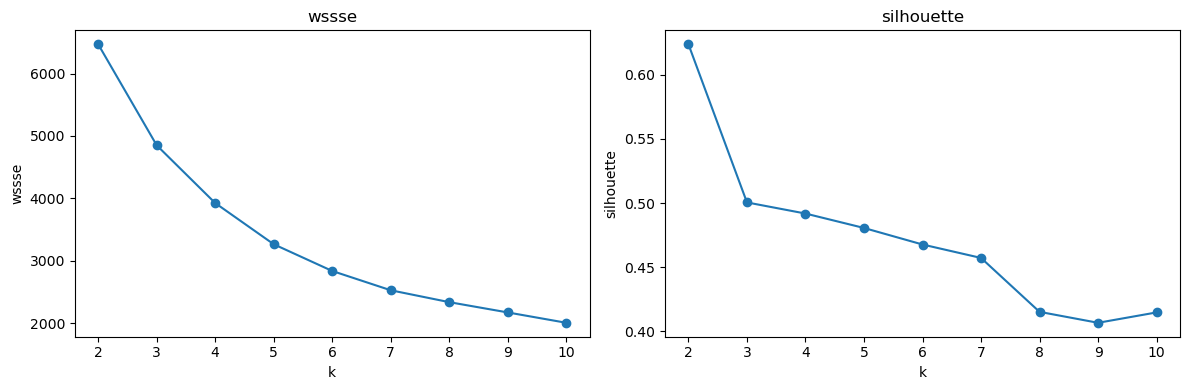

In [8]:
if SCORES_PATH.exists():
    k_scores = pd.read_csv(SCORES_PATH)
    assert {"k", "wssse", "silhouette"}.issubset(k_scores.columns)
    assert k_scores["k"].is_unique
    assert np.isfinite(k_scores[["wssse", "silhouette"]].to_numpy(dtype=float)).all()
    assert k_scores["wssse"].ge(0).all() and k_scores["silhouette"].between(-1, 1).all()
    display(k_scores)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["wssse", "silhouette"]):
        ax.plot(k_scores["k"], k_scores[metric], marker="o")
        ax.set(xlabel="k", ylabel=metric, title=metric)
        ax.set_xticks(k_scores["k"])
    plt.tight_layout()
    plt.show()
else:
    print("Input/output validation; see the displayed tables and configured paths.")

## G. Kết luận và kiểm chứng

Đọc bảng tổng hợp cùng profile, transition hai chiều và score. k=4 có thể phục vụ nhu cầu phân biệt moderate theo mức độ gần đây; đây là lựa chọn diễn giải, không chứng minh k=4 tối ưu.

Chưa kiểm tra nhiều seed, ổn định qua thời gian, hiệu quả chiến dịch hay nhãn churn thật. Nếu thay dữ liệu, cập nhật kết luận và số liệu trong guide.

In [9]:
summary = profile_display[["k", "Cluster", "Segment", "n_customers", "customer_pct",
                           "recency_median", "frequency_median", "monetary_median", "monetary_pct"]]
display(summary.round(2))
for k, data in rfm_by_k.items():
    assert comparison_profile.loc[k, "n_customers"].sum() == len(data)
    assert np.isclose(comparison_profile.loc[k, "customer_pct"].sum(), 100)
    assert np.isclose(comparison_profile.loc[k, "monetary_pct"].sum(), 100)
assert labels.notna().all().all() and len(labels) == len(baseline)
print("Input/output validation; see the displayed tables and configured paths.")

,k,Cluster,Segment,n_customers,customer_pct,recency_median,frequency_median,monetary_median,monetary_pct
0,2,0,Lower-value,2671,61.63,97.0,1.0,356.85,15.05
1,2,1,Higher-value,1663,38.37,17.0,6.0,2035.08,84.95
2,3,0,Lower-value,1872,43.19,160.0,1.0,292.74,7.69
3,3,1,Higher-value,753,17.37,10.0,10.0,3640.67,68.06
4,3,2,Intermediate,1709,39.43,30.0,3.0,958.71,24.25
5,4,0,Less-recent Moderate,1050,24.23,82.5,3.0,1018.60,17.95
6,4,1,Higher-value,691,15.94,10.0,10.0,3901.81,65.53
7,4,2,Lower-value,1528,35.26,159.5,1.0,236.03,4.60
8,4,3,Recent Moderate,1065,24.57,17.0,3.0,812.68,11.92


Input/output validation; see the displayed tables and configured paths.
